100%|██████████| 65/65 [00:09<00:00,  6.86it/s]


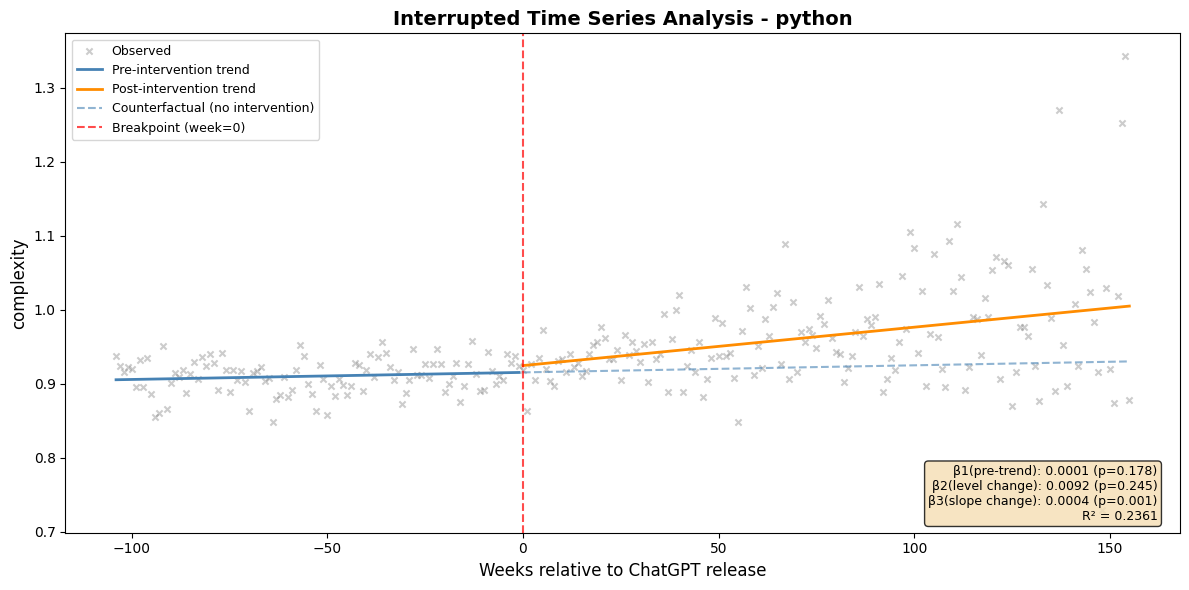

100%|██████████| 65/65 [00:07<00:00,  8.48it/s]


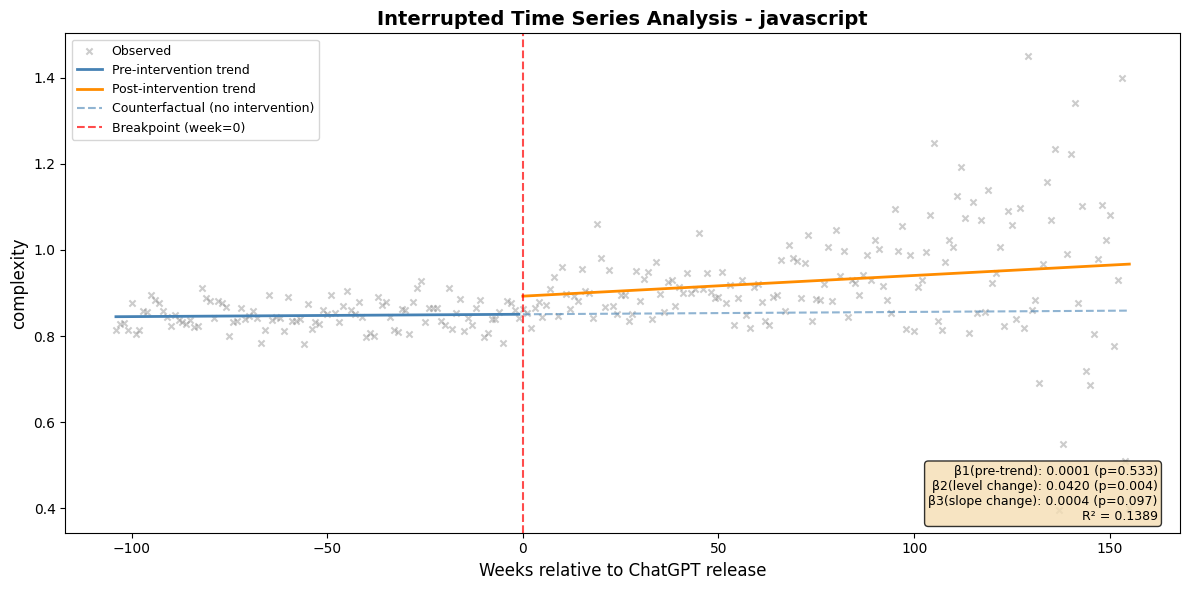

100%|██████████| 65/65 [00:03<00:00, 16.48it/s]


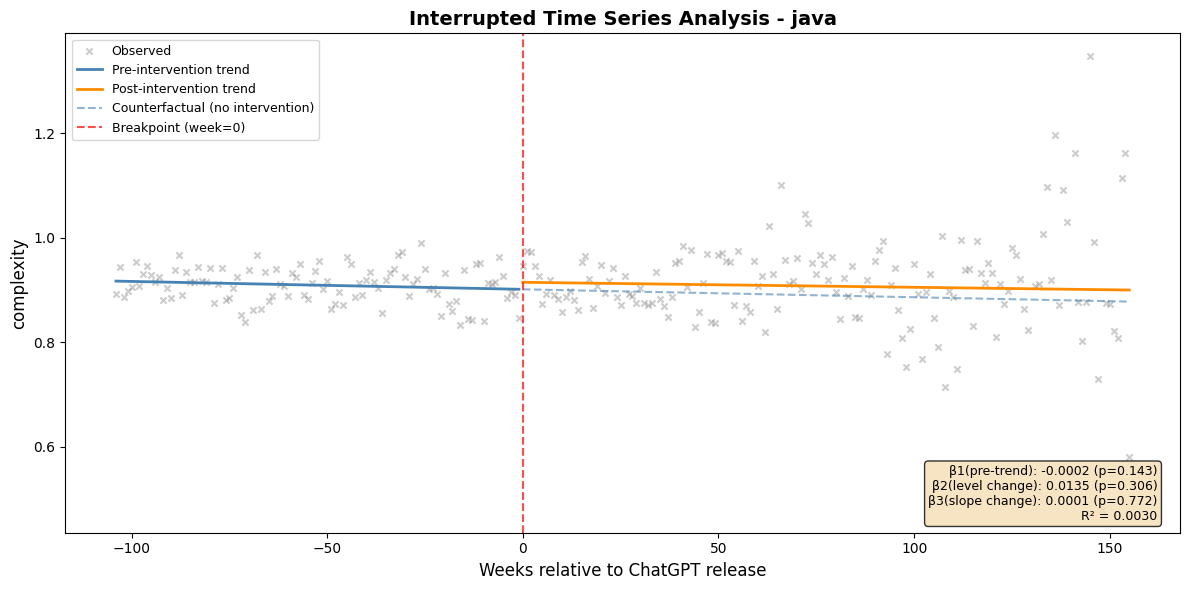

100%|██████████| 65/65 [00:02<00:00, 22.52it/s]


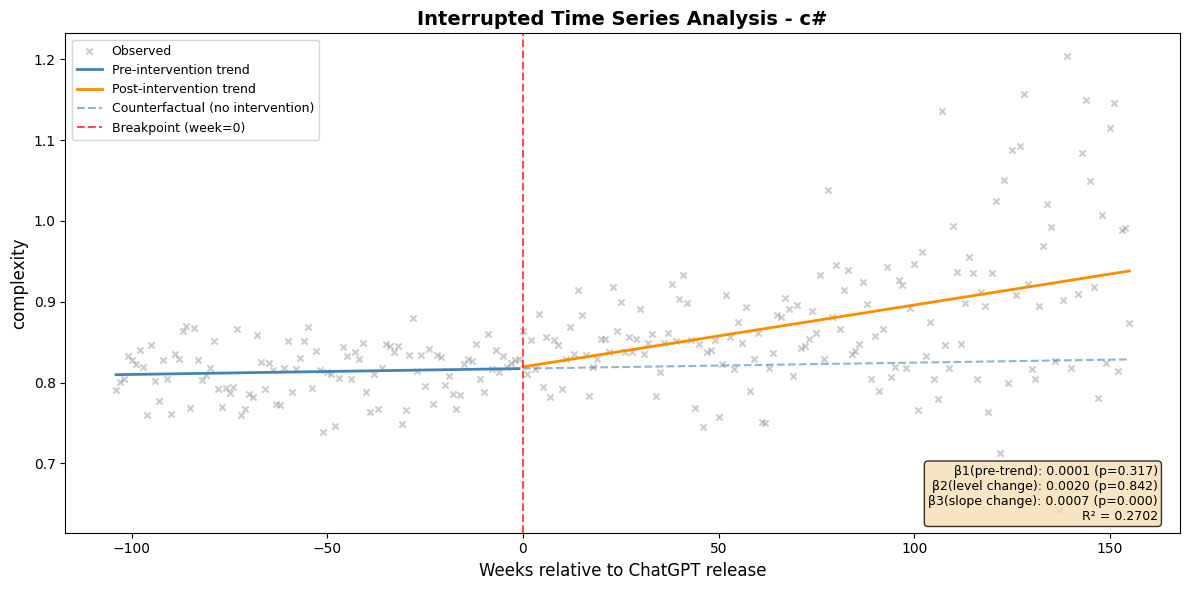

100%|██████████| 65/65 [00:01<00:00, 36.64it/s]


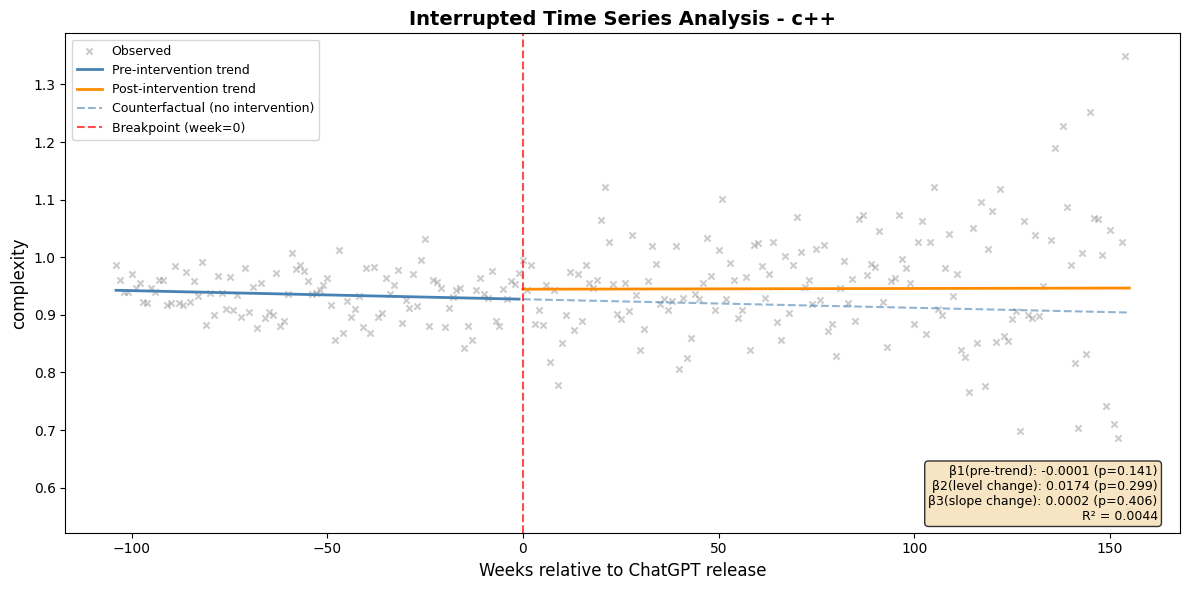

100%|██████████| 65/65 [00:00<00:00, 69.37it/s]


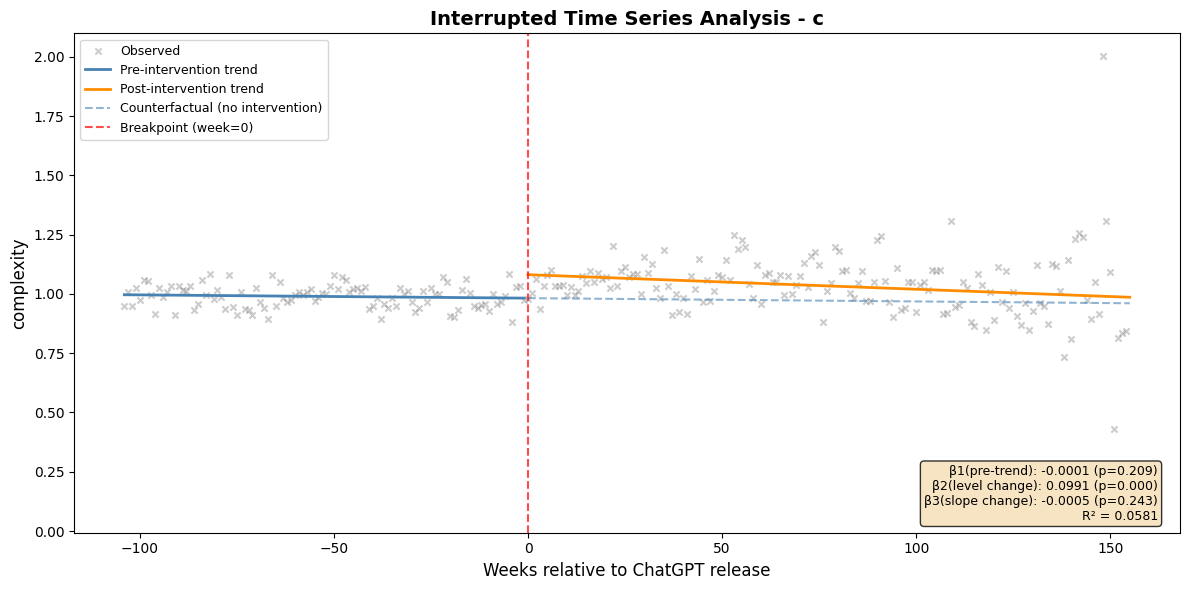

100%|██████████| 65/65 [00:01<00:00, 33.25it/s]


ValueError: r_matrix performs f_test for using dimensions that are asymptotically non-normal

In [7]:
"""
Interrupted Time Series (ITS) Analysis Template
=================================================
- 데이터 형태: 주차별 숫자 인덱스 (weeks relative to ChatGPT release)
- Breakpoint: week = 0 (ChatGPT 출시 시점)
- Model: y = β0 + β1·time + β2·post + β3·(time × post) + ε

"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_breuschpagan
import matplotlib.pyplot as plt

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting


from lib.utils.file_io import *
from lib.code_complexity.cognitive_complexity import calculate_cognitive_complexity


def load_and_prepare(run_id, lang):
    """데이터 로드 및 ITS 변수 생성"""

    print(f'[ITS....] load_and_prepare {lang} language')
    viz_dir = f'{path_list["data_root_dir"]}/result/code_complexity/run_id_{run_id}'
    option_dict = load_json(f"{viz_dir}/data/option.json")
    
    df = read_complexity_parquet(option_dict)
    df = calculate_cognitive_complexity(df, 'max')
    origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])


    viz_df = pd.merge(df, origin_df, on = 'id')[['id', 'creationdate', 'Cognitive Complexity']]
    viz_df['rel_week'] = np.floor((pd.to_datetime(viz_df['creationdate'], format='mixed')- \
                                   Date_Setting[option_dict['year_range']]['std_date']).dt.days/7)
    viz_df = (viz_df.groupby('rel_week', as_index=False)['Cognitive Complexity'].std())
    viz_df = viz_df.rename(columns={'Cognitive Complexity': 'complexity'})


    df = viz_df.sort_values('rel_week')

    # --- ITS 변수 생성 ---
    # time: 주차 인덱스 그대로 사용
    df["time"] = df['rel_week']

    # post: 개입 이후 = 1, 이전 = 0
    df["post"] = (df['rel_week'] >= 0).astype(int)

    # time_after: 개입 이후 경과 주 수 (개입 전은 0)
    df["time_after"] = np.where(df["post"] == 1, df['rel_week'] - 0, 0)

    return df


def run_its_regression(df, y_col, use_robust=True):
    """
    ITS 회귀분석 수행

    모형: y = β0 + β1·time + β2·post + β3·time_after + ε

    β0: 기저 수준 (intercept)
    β1: 개입 전 기존 추세 (pre-intervention trend)
    β2: 개입 시점의 수준 변화 (level change, immediate effect)
    β3: 개입 후 추세 변화 (slope change, gradual effect)
         → 개입 후 전체 기울기 = β1 + β3
    """
    X = df[["time", "post", "time_after"]]
    X = sm.add_constant(X)
    y = df[y_col]

    if use_robust:
        model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
    else:
        model = sm.OLS(y, X).fit()

    return model


def diagnostic_tests(model, df, y_col):
    """잔차 진단 검정"""
    print("\n" + "=" * 60)
    print("진단 검정 (Diagnostic Tests)")
    print("=" * 60)

    X = df[["time", "post", "time_after"]]
    X = sm.add_constant(X)
    y = df[y_col]

    # 1) Breusch-Godfrey 자기상관 검정
    try:
        bg_stat, bg_pval, _, _ = acorr_breusch_godfrey(
            sm.OLS(y, X).fit(), nlags=4
        )
        print(f"\n[자기상관] Breusch-Godfrey (lag=4)")
        print(f"  LM statistic = {bg_stat:.4f}, p-value = {bg_pval:.4f}")
        if bg_pval < 0.05:
            print("  → 자기상관 존재 가능 → HAC 표준오차 사용 권장 (이미 적용됨)")
        else:
            print("  → 유의한 자기상관 없음")
    except Exception as e:
        print(f"  Breusch-Godfrey 검정 실패: {e}")

    # 2) Breusch-Pagan 이분산 검정
    try:
        ols_result = sm.OLS(y, X).fit()
        bp_stat, bp_pval, _, _ = het_breuschpagan(ols_result.resid, X)
        print(f"\n[이분산] Breusch-Pagan")
        print(f"  LM statistic = {bp_stat:.4f}, p-value = {bp_pval:.4f}")
        if bp_pval < 0.05:
            print("  → 이분산 존재 가능 → HAC 표준오차 사용 권장 (이미 적용됨)")
        else:
            print("  → 유의한 이분산 없음")
    except Exception as e:
        print(f"  Breusch-Pagan 검정 실패: {e}")

    # 3) Durbin-Watson
    dw = sm.stats.stattools.durbin_watson(sm.OLS(y, X).fit().resid)
    print(f"\n[자기상관] Durbin-Watson statistic = {dw:.4f}")
    if dw < 1.5:
        print("  → 양의 자기상관 의심")
    elif dw > 2.5:
        print("  → 음의 자기상관 의심")
    else:
        print("  → 대체로 양호")


def interpret_results(model):
    """결과 해석 출력"""
    print("\n" + "=" * 60)
    print("결과 해석")
    print("=" * 60)

    params = model.params
    pvalues = model.pvalues
    conf = model.conf_int()

    def sig_label(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        elif p < 0.1:
            return "†"
        else:
            return "(n.s.)"

    print(f"\n1) 개입 전 기존 추세 (β1: time)")
    print(f"   계수 = {params['time']:.6f} {sig_label(pvalues['time'])}")
    print(f"   p-value = {pvalues['time']:.4f}")
    print(f"   95% CI: [{conf.loc['time', 0]:.6f}, {conf.loc['time', 1]:.6f}]")
    if pvalues["time"] < 0.05:
        direction = "증가" if params["time"] > 0 else "감소"
        print(f"   → 개입 전에도 유의한 {direction} 추세가 존재했음")
    else:
        print(f"   → 개입 전 유의한 추세 없음 (flat)")

    print(f"\n2) 개입 시점 수준 변화 (β2: post)")
    print(f"   계수 = {params['post']:.6f} {sig_label(pvalues['post'])}")
    print(f"   p-value = {pvalues['post']:.4f}")
    print(f"   95% CI: [{conf.loc['post', 0]:.6f}, {conf.loc['post', 1]:.6f}]")
    if pvalues["post"] < 0.05:
        direction = "상승" if params["post"] > 0 else "하락"
        print(f"   → ChatGPT 출시 시점에 즉각적인 수준 {direction}이 있었음")
    else:
        print(f"   → 즉각적인 수준 변화는 유의하지 않음")

    print(f"\n3) 개입 후 추세 변화 (β3: time_after)")
    print(f"   계수 = {params['time_after']:.6f} {sig_label(pvalues['time_after'])}")
    print(f"   p-value = {pvalues['time_after']:.4f}")
    print(f"   95% CI: [{conf.loc['time_after', 0]:.6f}, {conf.loc['time_after', 1]:.6f}]")
    if pvalues["time_after"] < 0.05:
        direction = "가팔라짐" if params["time_after"] > 0 else "완만해짐"
        print(f"   → 개입 후 추세가 유의하게 {direction}")
    else:
        print(f"   → 개입 후 추세 변화가 유의하지 않음")

    post_slope = params["time"] + params["time_after"]
    print(f"\n4) 개입 후 전체 기울기 (β1 + β3) = {post_slope:.6f}")
    print(f"   (개입 전 기울기: {params['time']:.6f})")


def plot_its(df, y_col, week_col, breakpoint, model, lang):
    """ITS 시각화"""
    fig, ax = plt.subplots(figsize=(12, 6))

    # 산점도
    ax.scatter(df[week_col], df[y_col], color="gray", alpha=0.4, s=20, marker="x", label="Observed")

    # 예측값
    X = sm.add_constant(df[["time", "post", "time_after"]])
    df["predicted"] = model.predict(X)

    # 구간별 피팅 라인
    pre = df[df["post"] == 0]
    post = df[df["post"] == 1]

    ax.plot(pre[week_col], pre["predicted"], color="steelblue", linewidth=2, label="Pre-intervention trend")
    ax.plot(post[week_col], post["predicted"], color="darkorange", linewidth=2, label="Post-intervention trend")

    # Counterfactual (개입이 없었다면의 추세 연장선)
    post_cf = post.copy()
    post_cf["predicted_cf"] = (
        model.params["const"]
        + model.params["time"] * post_cf["time"]
    )
    ax.plot(
        post_cf[week_col], post_cf["predicted_cf"],
        color="steelblue", linewidth=1.5, linestyle="--", alpha=0.6,
        label="Counterfactual (no intervention)"
    )

    # Breakpoint 수직선
    ax.axvline(x=breakpoint, color="red", linestyle="--", alpha=0.7, label=f"Breakpoint (week={breakpoint})")

    # 꾸미기
    ax.set_xlabel("Weeks relative to ChatGPT release", fontsize=12)
    ax.set_ylabel(y_col, fontsize=12)
    ax.set_title(f"Interrupted Time Series Analysis - {lang}", fontsize=14, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()

    # 결과 텍스트 박스
    textstr = (
        f"β1(pre-trend): {model.params['time']:.4f} (p={model.pvalues['time']:.3f})\n"
        f"β2(level change): {model.params['post']:.4f} (p={model.pvalues['post']:.3f})\n"
        f"β3(slope change): {model.params['time_after']:.4f} (p={model.pvalues['time_after']:.3f})\n"
        f"R² = {model.rsquared:.4f}"
    )
    ax.text(
        0.98, 0.02, textstr, transform=ax.transAxes,
        fontsize=9, verticalalignment="bottom", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
    )

    plt.savefig("its_result.png", dpi=150, bbox_inches="tight")
    print("\n→ 시각화 저장: its_result.png")
    plt.show()


def run_robustness_check(df, y_col, week_col, breakpoint, weeks_each_side):
    """
    Robustness check: 전후 동일 기간으로 잘라서 재검증

    weeks_each_side: breakpoint 전후로 유지할 주 수
                     (예: 104 → 전후 각 2년)
    """
    print("\n" + "=" * 60)
    print(f"Robustness Check (전후 각 {weeks_each_side}주)")
    print("=" * 60)

    df_trimmed = df[
        (df[week_col] >= breakpoint - weeks_each_side) &
        (df[week_col] < breakpoint + weeks_each_side)
    ].copy().reset_index(drop=True)

    df_trimmed["time"] = df_trimmed[week_col]
    df_trimmed["post"] = (df_trimmed[week_col] >= breakpoint).astype(int)
    df_trimmed["time_after"] = np.where(
        df_trimmed["post"] == 1, df_trimmed[week_col] - breakpoint, 0
    )

    print(f"  Pre:  {(df_trimmed['post'] == 0).sum()} obs")
    print(f"  Post: {(df_trimmed['post'] == 1).sum()} obs")

    model_robust = run_its_regression(df_trimmed, y_col)
    print(model_robust.summary())
    interpret_results(model_robust)

    return model_robust


# ============================================================
# 메인 실행
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Interrupted Time Series (ITS) Analysis")
    print("=" * 60)

    Y_COL = 'complexity'
    WEEK_COL = 'rel_week'
    
    run_id_start = 10000

    for idx, lang in enumerate(CONSTANTS.src_extend.keys()):
        print(f'[visualizing....] start visualizing {lang} language')
        log_file = open_log(f"{lang}_its_result_log.txt")

        # 1) 데이터 로드 및 준비
        df = load_and_prepare(run_id_start+idx, lang)
        

        print(f"\n데이터 로드 완료: {len(df)} rows")
        print(f"  Pre:  {(df['post'] == 0).sum()} obs")
        print(f"  Post: {(df['post'] == 1).sum()} obs")

        
        # 2) ITS 회귀분석 (HAC robust SE)
        print("\n" + "=" * 60)
        print("OLS Regression with HAC (Newey-West) Standard Errors")
        print("=" * 60)
        model = run_its_regression(df, Y_COL, use_robust=True)
        print(model.summary())

        # 3) 결과 해석
        interpret_results(model)

        # 4) 진단 검정
        diagnostic_tests(model, df, Y_COL)

        # 5) 시각화
        plot_its(df, Y_COL, WEEK_COL, 0, model, lang)

        close_log(log_file)

    # 6) Robustness check (전후 동일 기간)
    #    주석 해제하고 원하는 주 수를 넣으세요
    #    104주 = 2년, 78주 = 1.5년
    # run_robustness_check(df, Y_COL, WEEK_COL, BREAKPOINT, weeks_each_side=104)

In [6]:
print(model.summary(slim=True))

ValueError: r_matrix performs f_test for using dimensions that are asymptotically non-normal

In [12]:
df = pd.read_parquet('/mnt/hdd/mghan/so_difficulty_measure/result/code_complexity/run_id_10006/data/all_complexity.parquet')

In [ ]:
from datetime import datetime
df['rel_week'] = np.floor((pd.to_datetime(df['creationdate'], format='mixed')- \
                                   datetime(2022,11,30)).dt.days/7)

,Unnamed: 0,Path,File Name,Cognitive Complexity
0,0,65818_77439490.csv,65818_77439490.csv,0
1,0,151685_76607795.csv,151685_76607795.csv,0
2,0,83600_78094045.csv,83600_78094045.csv,0
3,0,143369_68019247.csv,143369_68019247.csv,0
4,1,143369_68019247.csv,143369_68019247.csv,4
...,...,...,...,...
21427,0,8064_79512034.csv,8064_79512034.csv,1
21428,0,193776_66683322.csv,193776_66683322.csv,5
21429,0,100183_65444008.csv,100183_65444008.csv,0
21430,0,51559_79782779.csv,51559_79782779.csv,11
